# Steps
- Extract patches from our data
- Dim Redux to 3D
- Cluster

In [1]:
import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset
import cutouts_to_patches.cutouts_to_patches as cutouts_to_patches

In [10]:
from cuml.manifold import UMAP

ModuleNotFoundError: No module named 'cuml'

In [3]:
import torch
from einops import rearrange
from matplotlib import pyplot as plt

import numpy as np
# from cuml.cluster import HDBSCAN
# from cuml.cluster import DBSCAN
# from cuml.cluster import AgglomerativeClustering
# import cupy as cp
# import cuml.cluster as cuml_cluster
import itertools

In [4]:
# from umap import umap_ as umap

In [5]:
source = cutouts_dataset.CutoutDataSource(bucket="dbof", folder="cutouts_dataset_v2_TESTING",
                                          run_id="itest_d7af6005",
                                          dataset_name="cutout_dataset_creation.zarr",
                                          s3_endpoint="https://s3-west.nrp-nautilus.io"
                                          )

source.print_available_channels()

20 available channels:
['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','SIarea','XC','YC']


In [6]:
# cutouts_dataloader = cutouts_dataset.get_cutout_loader(source=source, subset=True, subsample_per_chunk = 64, num_sample_chunks = 1, n_workers=1, batch_size=64)
data_channels = ['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f']

cutouts_dataloader = cutouts_dataset.get_cutout_loader(data_channels=data_channels, source=source, subset=False, subsample_per_chunk = 64, num_sample_chunks = 1, n_workers=1, batch_size=64)

/Users/jaketallman/PycharmProjects/DBOF_Representation_Learning/.venv1/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 55123 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:55124' processes=1 threads=10, memory=24.00 GiB>
nrp link url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/55123/status
dropped 0 cutouts with sea ice
dropped 0 cutouts with NaN
kept 292 / 292 cutouts
Channels : ['Eta', 'Salt', 'Theta', 'U', 'V', 'W', 'gradb2', 'oceTAUX', 'oceTAUY', 'gradrho2', 'turner_angle', 'strain_n', 'strain_s', 'strain_mag', 'divergence', 'relative_vorticity', 'coriolis_f', 'XC', 'YC']


In [9]:
print(len(cutouts_dataloader))

5


AttributeError: 'DataLoader' object has no attribute 'channel_names'

5
torch.Size([64, 19, 64, 64])
torch.Size([64, 64, 19, 8, 8])


/Users/jaketallman/PycharmProjects/DBOF_Representation_Learning/.venv1/lib/python3.12/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


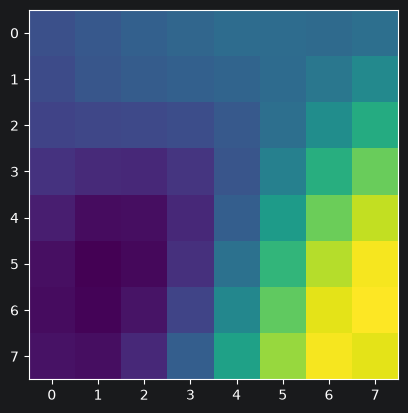

In [7]:
print(len(cutouts_dataloader))
for batch in cutouts_dataloader:
    print(batch.shape)
    
    patches = cutouts_to_patches.images_to_patches(batch, 8)
    print(patches.shape)

    img = patches[0][0][0]
# for patches in patched_loader:
    plt.imshow(img)

    break

In [8]:
patch_size = 8
patched_loader = cutouts_to_patches.PatchedDataLoader(cutouts_dataloader, patch_size=patch_size)
print(len(patched_loader))

patches = torch.cat(
    [patches.reshape(patches.shape[0] * patches.shape[1], -1) for patches in patched_loader], dim=0
).numpy()

print(patches.shape)


5
(18688, 1216)


In [9]:
def vis_dim_redux(X_d, labels=None, class_subset=None, label_title="class", dims=2):  

    labels = labels

    if dims ==2:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111)

        if labels is not None :
    
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                c=labels,
                cmap="tab10",
                alpha=0.07,
                s=.1
            )

        else :
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                alpha=0.07,
                s=.1
            )
    
        ax.set_xlabel("C1")
        ax.set_ylabel("C2")
    
        legend = ax.legend(*scatter.legend_elements(), title=label_title)
        ax.add_artist(legend)

    if dims == 3:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')

        if labels is not None :
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                X_d[:,2],
                c=labels,
                s=.1,
                cmap="tab10",
                alpha=0.07
            )

        else :
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                X_d[:,2],
                alpha=0.07,
                s=.1
            )
            
    
        ax.set_xlabel("C1")
        ax.set_ylabel("C2")
        ax.set_zlabel("C3")
    
        legend = ax.legend(*scatter.legend_elements(), title=label_title)
        ax.add_artist(legend)

plt.show()

# Umap

[2026-04-02 00:51:03.330] [CUML] [warning] build_algo='nn_descent' requires `nnd_graph_degree >= n_neighbors`. Setting nnd_graph_degree to 200
[2026-04-02 00:51:03.330] [CUML] [warning] build_algo='nn_descent' requires `nnd_intermediate_graph_degree >= nnd_graph_degree`. Setting nnd_intermediate_graph_degree to 200


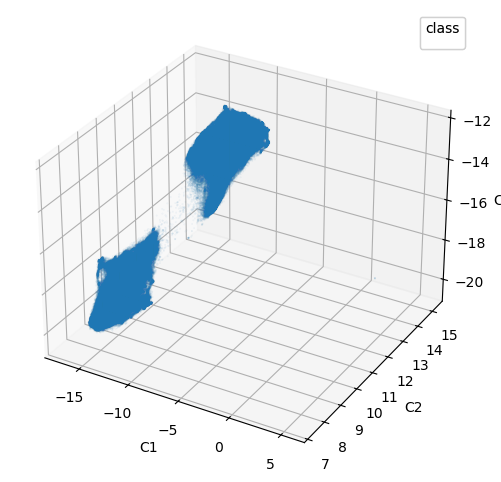

In [30]:
reducer = UMAP(
    n_components=3,
    n_neighbors=200,
    min_dist=0.0,
)
patches_3d = reducer.fit_transform(patches)

vis_dim_redux(patches_3d, dims=3)

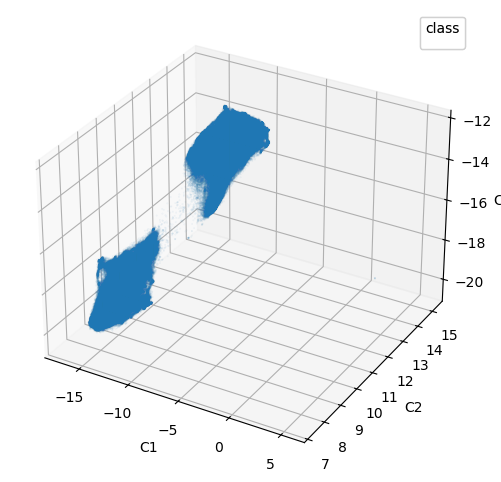

In [31]:
vis_dim_redux(patches_3d, dims=3)

In [32]:
# 10d
reducer = UMAP(
    n_components=10,
    n_neighbors=3,
    min_dist=0.0,
)
patches_10d = reducer.fit_transform(patches)

[2026-04-07 17:31:29.088] [CUML] [warning] build_algo='nn_descent' requires `nnd_graph_degree >= n_neighbors`. Setting nnd_graph_degree to 500
[2026-04-07 17:31:29.088] [CUML] [warning] build_algo='nn_descent' requires `nnd_intermediate_graph_degree >= nnd_graph_degree`. Setting nnd_intermediate_graph_degree to 500


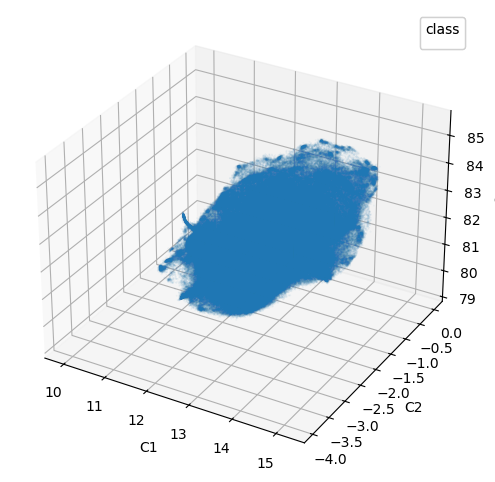

In [37]:
reducer = UMAP(
    n_components=3,
    n_neighbors=500,
    min_dist=0.0,
)
patches_3d = reducer.fit_transform(patches)

vis_dim_redux(patches_3d, dims=3)

In [13]:
reducer = UMAP(
    n_components=2,
    n_neighbors=500,
    min_dist=0.0,
)
patches_2d = reducer.fit_transform(patches)

[2026-04-07 16:53:41.799] [CUML] [warning] build_algo='nn_descent' requires `nnd_graph_degree >= n_neighbors`. Setting nnd_graph_degree to 500
[2026-04-07 16:53:41.799] [CUML] [warning] build_algo='nn_descent' requires `nnd_intermediate_graph_degree >= nnd_graph_degree`. Setting nnd_intermediate_graph_degree to 500


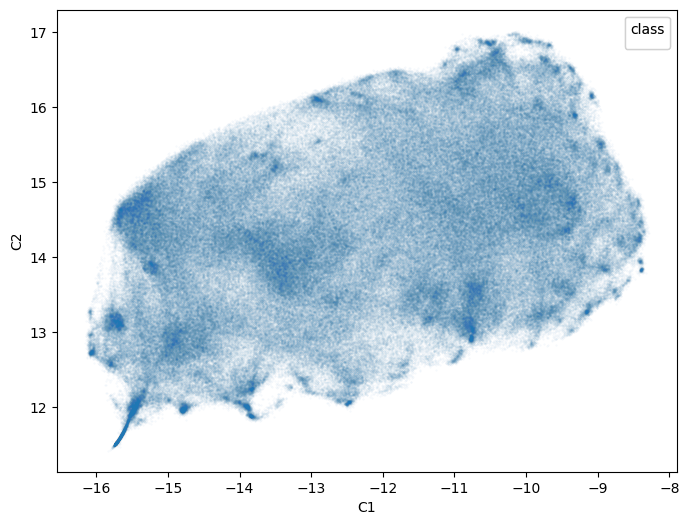

In [14]:
vis_dim_redux(patches_2d, dims=2)

# Cluster

In [15]:
# patches_3d = patches_3d / np.linalg.norm(patches_3d, axis=1, keepdims=True)

In [38]:
X_gpu = cp.asarray(patches_3d)
X_gpu_2D = cp.asarray(patches_2d)
X_gpu_10D = cp.asarray(patches_10d)

# HCA

I don't think we can use the gpu accelerated version as it does not give distances. We can only use this if we have k. 

In [35]:
# # FIT the graph whith GPU acceleration
# model = AgglomerativeClustering(
#     n_clusters=1,
#     connectivity='knn',
#     linkage='single',
#     c=15
# )
# model.fit(X_gpu)

# children = np.array(model.children_.get())
# X = patches_3d

# # The gpu accelerated version does not give merge lengths, so I cannot make a decision on cuts with this alone
# # I am moving the chiildren which is the generated graph to sklearn (cpu) 
# # I am calculating distances myself

# from scipy.cluster.hierarchy import dendrogram

# n_samples = len(X)
# print(n_samples)
# print(children.shape)
# print(children[0])

# # Cluster size for each node, needed for approx distance
# cluster_size = np.ones(2 * n_samples - 1)
# for i, (left, right) in enumerate(children):
#     cluster_size[n_samples + i] = cluster_size[left] + cluster_size[right]

# # This is using merge step as a proxy for distance which is pretty bad. 
# Z = np.column_stack([
#     children,
#     np.arange(1, len(children) + 1, dtype=float), 
#     cluster_size[n_samples:]                         
# ])

# # Plot
# plt.figure(figsize=(12, 5))
# dendrogram(Z, truncate_mode='lastp', p=30, show_leaf_counts=True)
# plt.ylabel('Merge step (proxy distance)')
# plt.title('Dendrogram')
# plt.show()

### GPU accelerated with fixed k

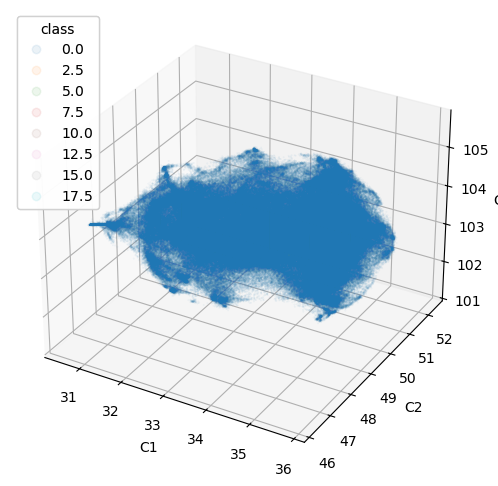

In [17]:
k = 20 
model = AgglomerativeClustering(
    n_clusters=k,
    connectivity='knn',
    linkage='single',
    c=15
)
model.fit(X_gpu)

labels = model.labels_.get()
vis_dim_redux(patches_3d, labels, dims=3)

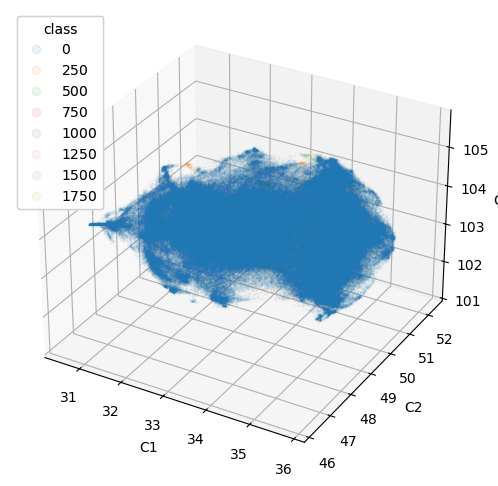

In [20]:
k = 2000
model = AgglomerativeClustering(
    n_clusters=k,
    connectivity='knn',
    linkage='single',
    c=15
)
model.fit(X_gpu)

labels = model.labels_.get()
vis_dim_redux(patches_3d, labels, dims=3)

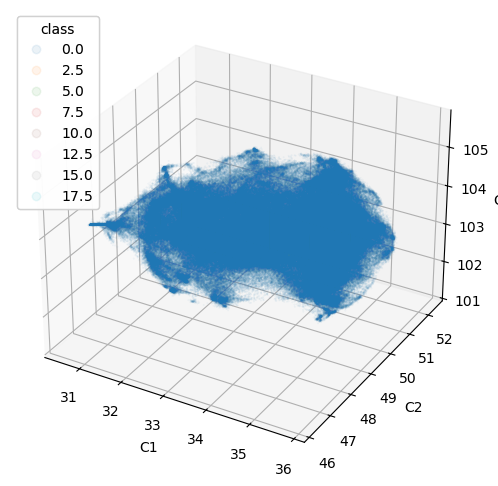

In [21]:
k = 20 
model = AgglomerativeClustering(
    n_clusters=k,
    connectivity='knn',
    linkage='single',
    c=2
)
model.fit(X_gpu)

labels = model.labels_.get()
vis_dim_redux(patches_3d, labels, dims=3)

In [34]:
# 10d version
k = 50 
model = AgglomerativeClustering(
    n_clusters=k,
    connectivity='knn',
    linkage='single',
    c=10
)
model.fit(X_gpu_10D)

labels = model.labels_.get()
print(labels)
model.n_connected_components_

[0 0 0 ... 0 0 0]


1

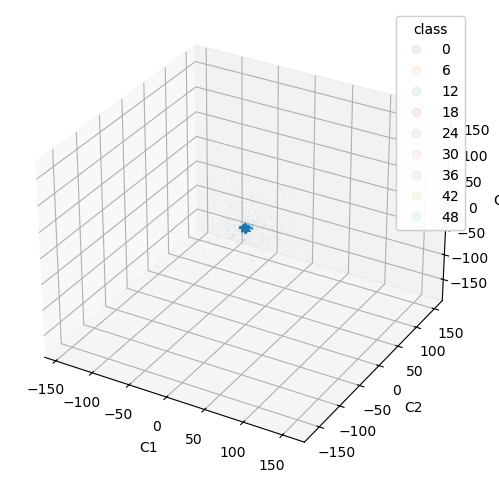

In [35]:
# I am not sure if the patches line up to the labels like this or not
vis_dim_redux(patches_3d, labels, dims=3)

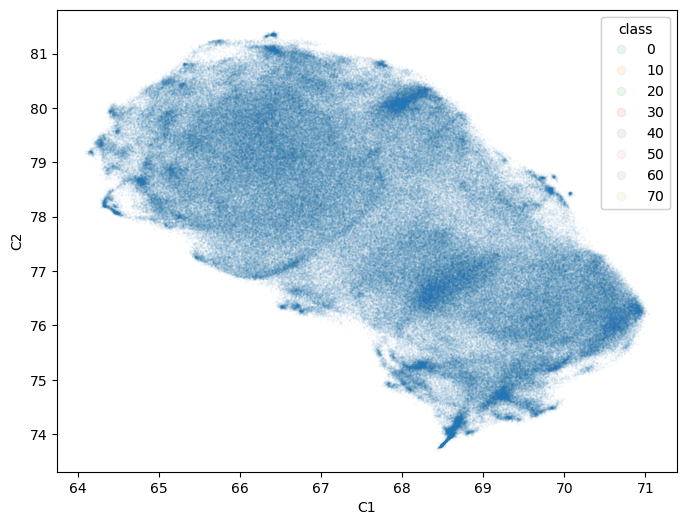

In [28]:
k = 80 
model = AgglomerativeClustering(
    n_clusters=k,
    connectivity='knn',
    linkage='single',
    c=15
)
model.fit(X_gpu_2D)

labels = model.labels_.get()
vis_dim_redux(patches_2d, labels, dims=2)

In [69]:
# Benchmark cpu version
import time
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


sample = patches_3d[:5000]
t0 = time.time()
Z = linkage(sample, method='ward')
elapsed = time.time() - t0

# Rough extrapolation
n_full = len(patches_3d)
n_sample = 5000
scale = (n_full**2 * np.log(n_full)) / (n_sample**2 * np.log(n_sample))
print(f"Sample took {elapsed:.1f}s ﷿﷿﷿ full estimate: {elapsed * scale:.0f}s")

Sample took 0.5s ﷿﷿﷿ full estimate: 9106s


In [47]:
# CPU approach


Z = linkage(patches_3d, method='ward', metric='euclidean')

# distances
merge_distances = Z[:, 2]
gaps = np.diff(merge_distances)

# Elbow
tail = 50
best_idx = np.argmax(gaps[-tail:])
k_optimal = tail - best_idx
print(f"Suggested k: {k_optimal}")

# Cut the tree
labels = fcluster(Z, t=k_optimal, criterion='maxclust')

Suggested k: 6


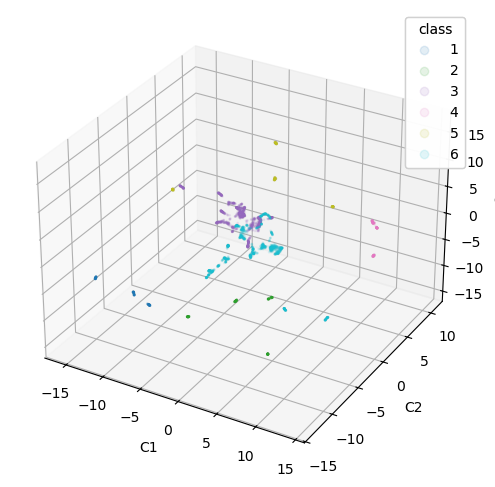

In [48]:
vis_dim_redux(patches_3d, labels, dims=3)

# DBSCAN

In [57]:
clusterer = DBSCAN(eps = 0.1, min_samples = 500, max_mbytes_per_batch=100)

clusterer.fit(X_gpu)
labels = clusterer.labels_.get()

print(f"Clusters found: {labels.max() + 1}")

Clusters found: 11


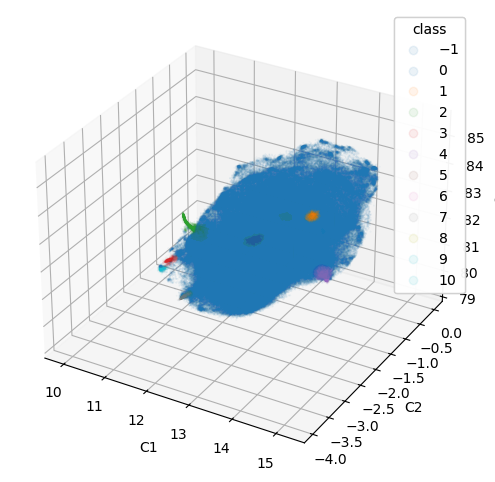

In [58]:
vis_dim_redux(patches_3d, labels, dims=3)

# HDBSCAN

In [61]:
clusterer = HDBSCAN(
    min_cluster_size=500,    
    min_samples=500,       
    prediction_data=True   
)

In [62]:
clusterer.fit(X_gpu)

HDBSCAN()

Clusters found: 29


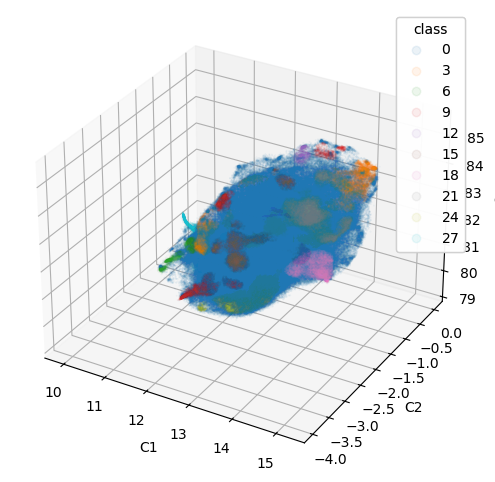

In [63]:
labels = clusterer.labels_.get()
print(f"Clusters found: {labels.max() + 1}")
vis_dim_redux(patches_3d, labels, dims=3)

Clusters found: 29
Unassigned:     0


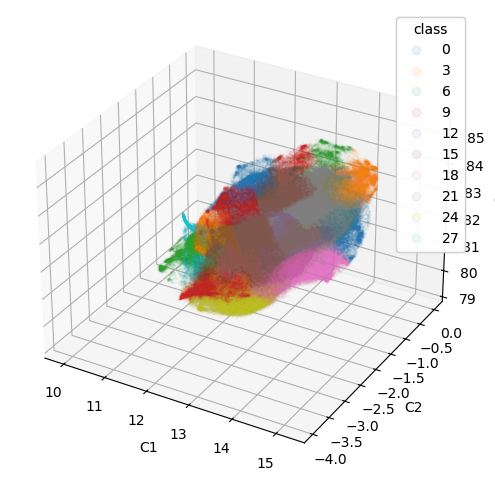

In [50]:
labels_soft = cuml_cluster.hdbscan.all_points_membership_vectors(clusterer)
labels = cp.asnumpy(labels_soft.argmax(axis=1)) 

print(f"Clusters found: {labels.max() + 1}")
print(f"Unassigned:     {(labels == -1).sum()}")

vis_dim_redux(patches_3d, labels, dims=3)

Clusters found: 2
Unassigned:     0


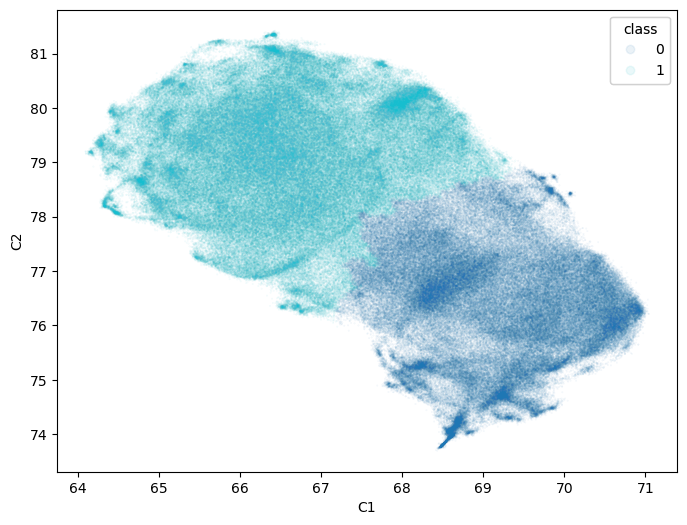

In [29]:
clusterer.fit(X_gpu_2D)

labels_soft_2d = cuml_cluster.hdbscan.all_points_membership_vectors(clusterer)
labels_2d = cp.asnumpy(labels_soft_2d.argmax(axis=1)) 

print(f"Clusters found: {labels_2d.max() + 1}")
print(f"Unassigned:     {(labels_2d == -1).sum()}")

vis_dim_redux(patches_2d, labels_2d, dims=2)

# Agglomerative

In [ ]:
# model = AgglomerativeClustering(n_clusters=10)
# model.fit(X_gpu)

# clusters = model.labels_.get()

# vis_dim_redux(patches_3d, clusters, dims=3)

In [ ]:
# reducer = UMAP(
#     n_components=2,
#     n_neighbors=15,
#     min_dist=0.1,
# )

# patches_2d = reducer.fit_transform(patches_3d)

# vis_dim_redux(patches_2d, clusters, dims=2)

# Display Clusters

In [32]:
labels

array([0, 0, 0, ..., 0, 0, 0], shape=(3776,), dtype=int32)

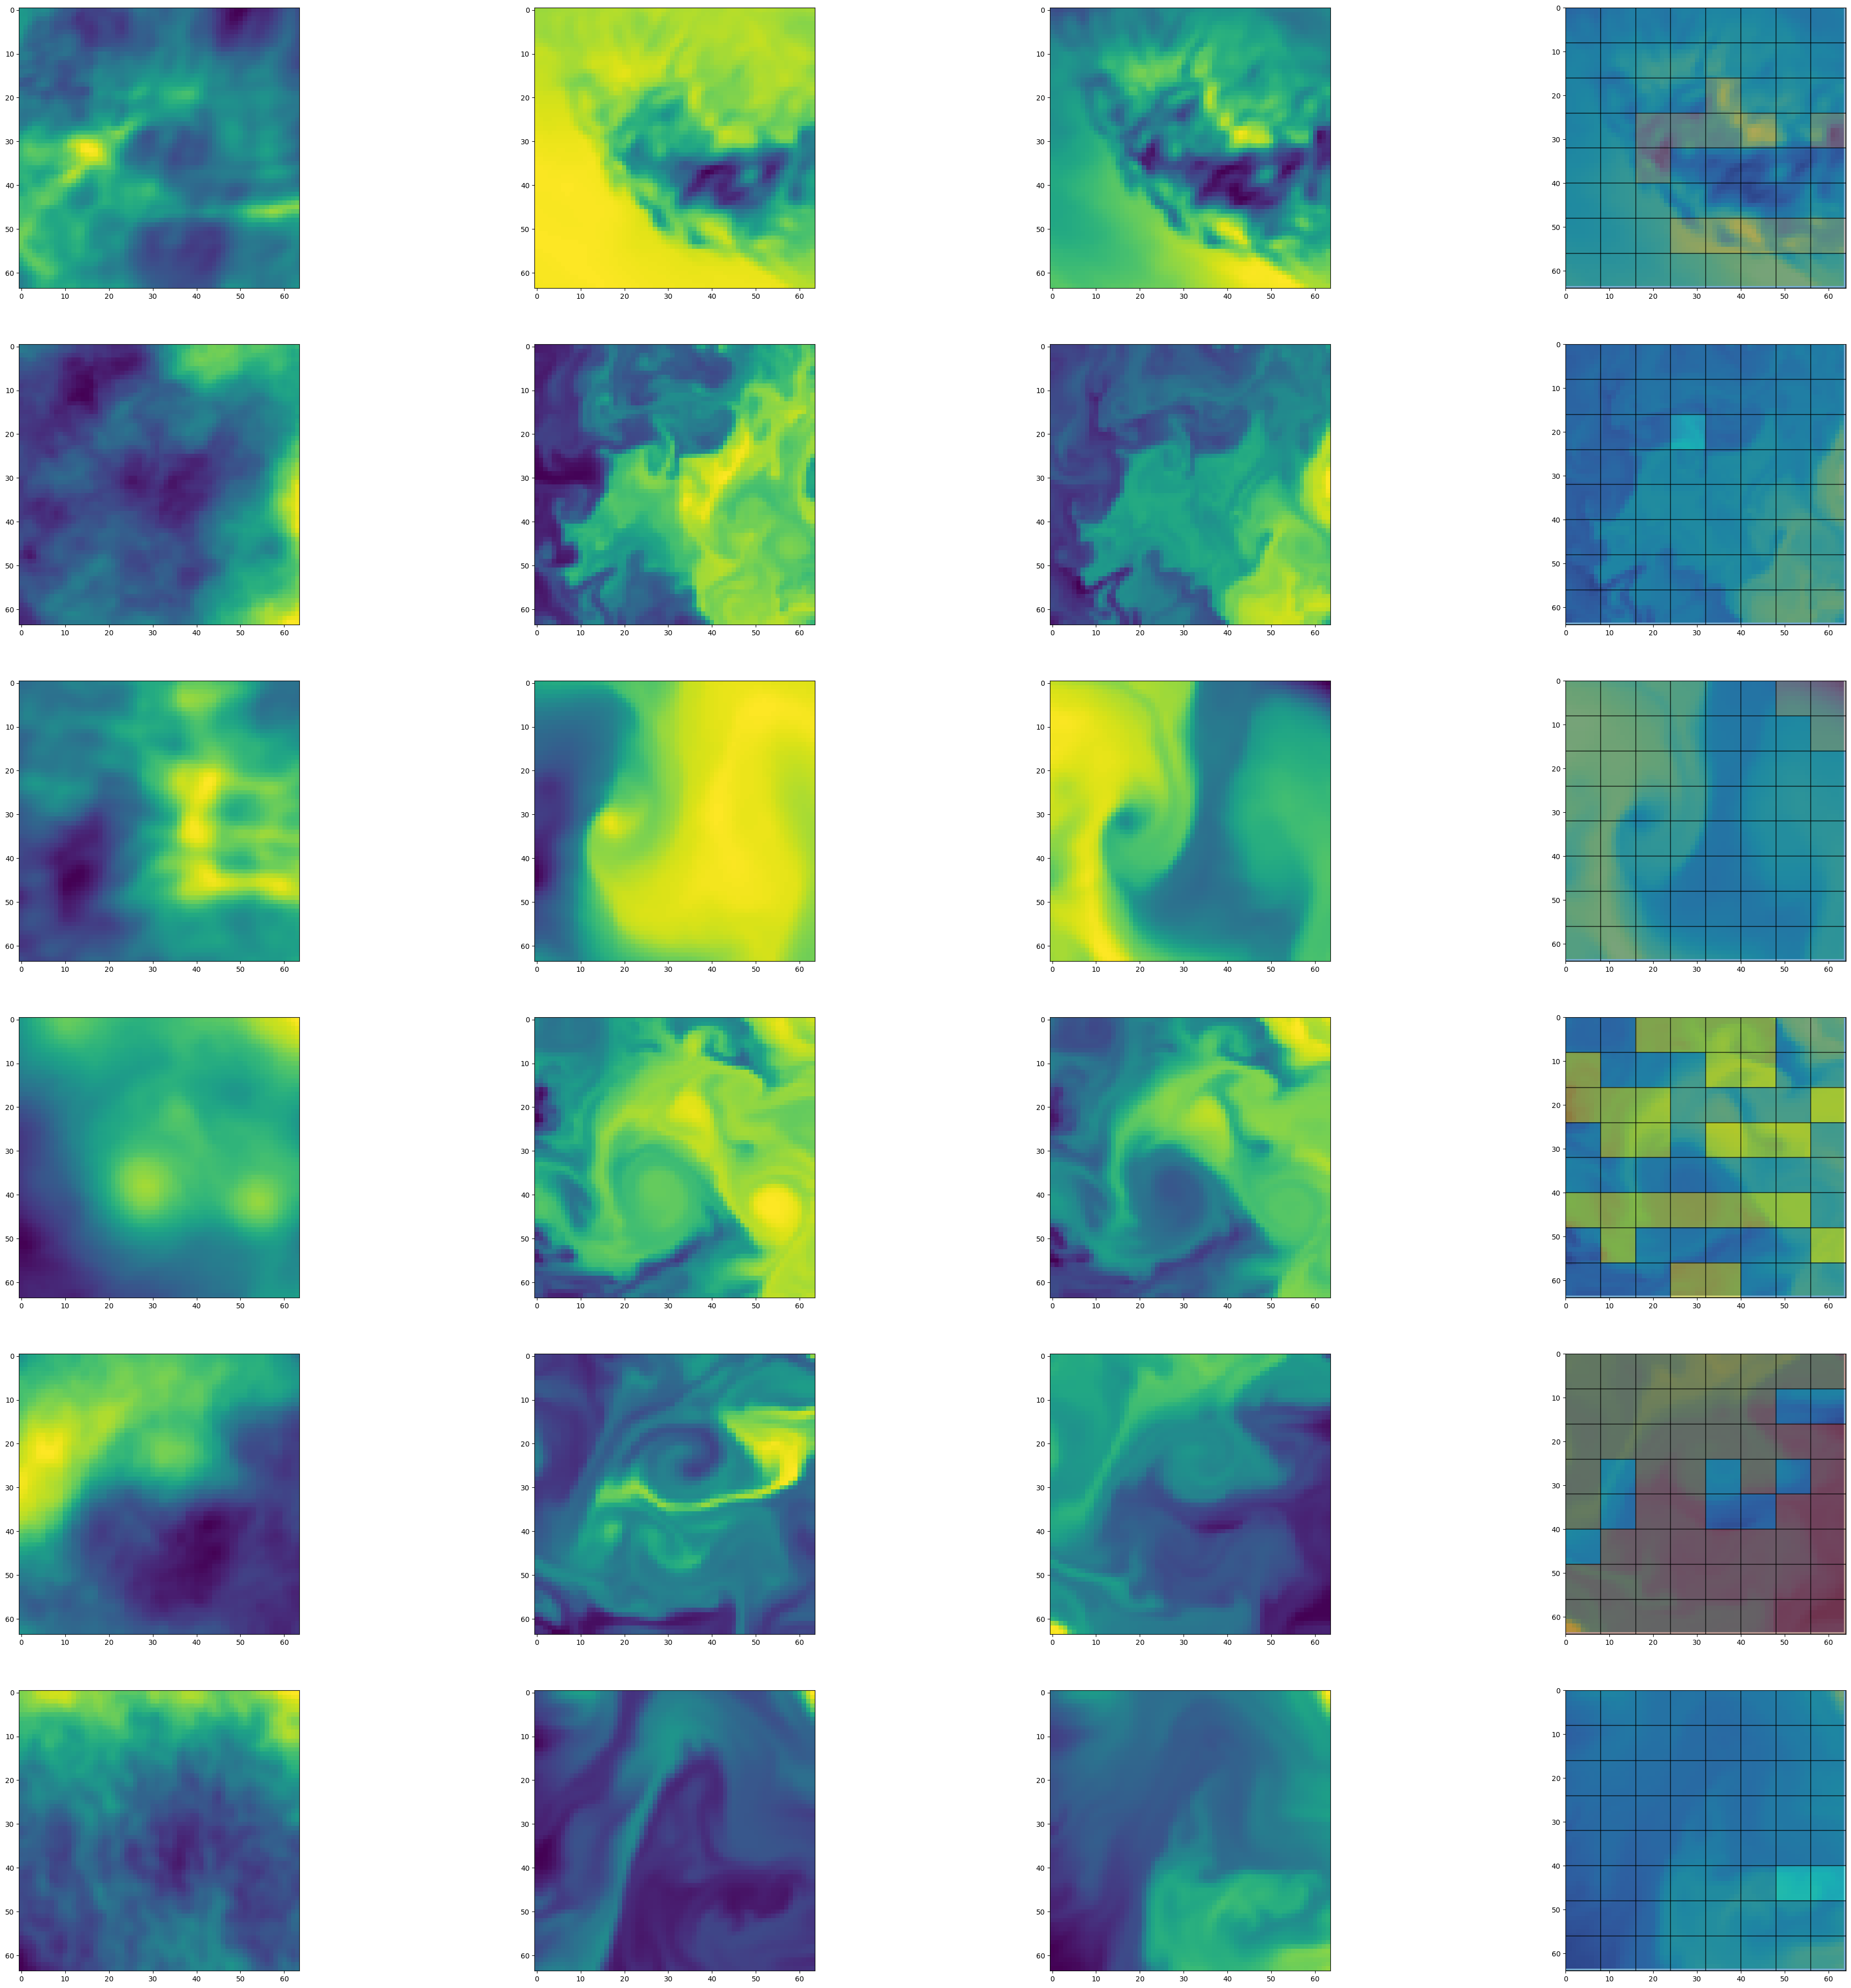

In [71]:
# Patches to Image
from einops import rearrange


# TODO check this logic. Labels don't seem to be placed accurately.
# I think I am seeting the same labels on different inputs 
def make_image_from_patches(cutouts_dataloader, patched_loader, labels, batch_index=0, 
                            batch_size=64, patches_per_image=64, patch_size=8,
                            cmap = "tab10", number_rows=6):
    
    cutouts_iter = iter(cutouts_dataloader)
    patches_iter = iter(patched_loader)
    fig, axes = plt.subplots(number_rows, 4, figsize=(50, 50))  
    
    batch_imgs = next(itertools.islice(cutouts_iter, batch_index, None))
    batch_patches =  next(itertools.islice(patches_iter, batch_index, None))

    
    for i in range(number_rows):
        img = batch_imgs[i]
        for c in range(3):
            c_img = img[c]
            axes[i,c].imshow(c_img)
            
    
        # reconstruct from patches for validation
        patches =  batch_patches[i]
        tmp_patches = patches[:,2,:,:]
        patches_tmp_img = rearrange(tmp_patches, '(h w) p1 p2 -> (h p1) (w p2)', h=8, w=8)
        axes[i,3].imshow(patches_tmp_img)
    
        
        # label grid
        patch_labels_start_index = (batch_index*batch_size*patches_per_image) + (i*patches_per_image) #todo double check this one more time
        patch_labels = labels[patch_labels_start_index:patch_labels_start_index+patches_per_image]
    
        H, W = c_img.shape[0], c_img.shape[1]
        n_patches_h = H // patch_size
        n_patches_w = W // patch_size
        label_grid   = patch_labels.reshape(n_patches_h, n_patches_w)
        n_clusters = labels.max() + 1
        axes[i,3].imshow(
            label_grid,
            cmap=cmap,
            alpha=0.6,
            vmin=0,
            vmax=n_clusters,
            extent=[0, W, H, 0],
            interpolation='nearest'
        )

        # Grid lines
        for g in range(0, H + 1, patch_size):
            axes[i,3].axhline(g, color='black', linewidth=1.5, alpha=0.6)
        for g in range(0, W + 1, patch_size):
            axes[i,3].axvline(g, color='black', linewidth=1.5, alpha=0.6)



make_image_from_patches(cutouts_dataloader, patched_loader, labels, batch_index=0, batch_size=64)